<a href="https://colab.research.google.com/github/Neilton-Cunha/Curso-3-Estatistica-/blob/main/Estat%C3%ADstica_com_Python_frequ%C3%AAncias_e_medidas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy

# Conhecendo os dados - Aula 1

In [ ]:
df = pd.read_csv('/content/dados.csv')
df.head()

,UF,Sexo,Idade,Cor,Anos de Estudo,Renda,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631


### Dado qualitativos

In [ ]:
# verificação de dados qualitativos ordinais
print(sorted(df['Anos de Estudo'].unique()))

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]


In [ ]:
# verificação de dados qualitativos nominais
print(sorted(df['UF' ].unique()))


[np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(31), np.int64(32), np.int64(33), np.int64(35), np.int64(41), np.int64(42), np.int64(43), np.int64(50), np.int64(51), np.int64(52), np.int64(53)]


In [ ]:
# verificação de dados qualitativos nominais
sorted(df['Sexo' ].unique())


[np.int64(0), np.int64(1)]

In [ ]:
# verificação de dados qualitativos nominais
sorted(df['Cor' ].unique())

[np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8)]

### Dados quantitativos

#### <font color='red'>Observação</font>
***
> A variável idade pode ser classificada de três formas distintas:
> 1. <b>QUANTITATIVA DISCRETA</b> - quando representa anos completos (números inteiros);
> 2. <b>QUANTITATIVA CONTÍNUA</b> - quando representa a idade exata, sendo representado por frações de anos; e
> 3. <b>QUALITATIVA ORDINAL</b> - quando representa faixas de idade.

In [ ]:
# verificação de dados quantitativos discreta
print('De %s até %s anos' % (df.Idade.min(), df.Idade.max()))



De 13 até 99 anos


In [ ]:
# verificação de dados quantitativos continua
print('De %s até %s metros' % (df['Altura'].min(), df.Altura.max()))
                                   # são duas formas de executar

De 1.339244614 até 2.028496765 metros


# Distribuição de frequencia - Aula 2

In [ ]:
print(df['Sexo'].value_counts())
print('-'*100)
round(df['Sexo'].value_counts(normalize = True) * 100)
# verificação por porcentagem

Sexo
0    53250
1    23590
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------


,proportion
Sexo,
0,69.0
1,31.0


### Formatando tabela no pandas

In [ ]:
# contagem de elementos da coluna sexo
frequencia = df['Sexo'].value_counts()

# converter a coluna sexo para porcentagem -> value_counts(normalize = True)
percentual = round(df['Sexo'].value_counts(normalize = True) * 100)

# criando dataframe para a tabela
dist_freq_qualitativas = pd.DataFrame({'Frequência': frequencia, 'Porcentagem (%)': percentual})

# nomeando valores da tabela original -> rename(index = {indice: 'nome', indice: 'nome'}, inplace = True)
# inplace = True -> equivale a ativar a linha
dist_freq_qualitativas.rename(index = {0: 'Masculino', 1: 'Feminino'}, inplace = True)

dist_freq_qualitativas.rename_axis('Sexo', axis = 'columns', inplace = True)

# elemento.reset_index() ->usado para redefinir o índice de um DataFrame ou Series
#dist_freq_qualitativas = dist_freq_qualitativas.reset_index()

dist_freq_qualitativas

Sexo,Frequência,Porcentagem (%)
Sexo,,
Masculino,53250,69.0
Feminino,23590,31.0


In [ ]:
# serve para apagar os indices numericos
dist_freq_qualitativas.style.hide(axis='index')
df.rename_axis('Matérias', axis = 'columns', inplace = True)

Sexo,Frequência,Porcentagem (%)
Masculino,53250,69.000000
Feminino,23590,31.000000


In [ ]:
sexo = {0: 'Masculino',
        1: 'Feminino'}

cor = {0: 'Indígena',
        2: 'Branca',
        4: 'Preta',
        6: 'Amarela',
        8: 'Parda',
        9: 'Sem declaração'}

A função `pd.crosstab()` é usada para construir uma tabela de frequência cruzada, também conhecida como tabela de contingência. Ela é ideal para analisar a relação entre duas ou mais variáveis categóricas. No exemplo da variável `frequencia`, ela mostra quantos indivíduos de cada 'Sexo' pertencem a cada 'Cor', criando um resumo claro da distribuição conjunta dessas duas características.

O **aggfunc** permite que você execute uma função de agregação (como média, soma, etc.) em uma coluna específica (values) em vez de simplesmente contar as ocorrências. No seu caso, ele calculou a renda média por 'Sexo' e 'Cor'.

In [ ]:
#frequencia = round(pd.crosstab(df['Sexo'], df['Cor'],
#                               normalize = True) *100, 1)

frequencia = round(pd.crosstab(df['Sexo'], df['Cor'],
                               aggfunc = 'mean', values = df['Renda']
                               ), 2)

# index = linha | columns = coluna
frequencia.rename(index = sexo, inplace = True)
frequencia.rename(columns = cor, inplace = True)
frequencia


Cor,Indígena,Branca,Preta,Amarela,Parda
Sexo,,,,,
Masculino,1081.71,2925.74,1603.86,4758.25,1659.58
Feminino,2464.39,2109.87,1134.60,3027.34,1176.76


### Distribuição de freq quant (personalizadas)

A: acima de 20;

B: de 10 a 20;

C: de 4 a 10;

D: de 2 a 4;

E: de zero até 2 salários mínimos.
Como a pesquisa PNAD na qual baseamos nossos dados foi realizada em 2015, o valor do salário mínimo era de R$788,00.

Com base nisso, faremos o cálculo dos valores em reais de cada classificação apresentada.

A: acima de 15.760,00;

B: de 7.880,00 até 15.760,00;

C: de 3.152,00 até 7.880,00;

D: de 1.576,00 até 3.152,00;

E: de zero até 1.576,00.

A função pd.cut() do Pandas é utilizada para transformar dados numéricos contínuos em categorias discretas (bins/intervalos). É ideal para criar faixas etárias, grupos de renda ou intervalos de preços

In [ ]:
Salario = [0, 1576, 3152, 7880, 15760, 20612]
Classe = ['E', 'D', 'C', 'B', 'A']

# pd.cut(x, bins, labels=None, right=True)
frequencia = pd.cut(df.Renda, Salario, labels = Classe,
                    include_lowest = True).value_counts()

percentual = round(pd.cut(df.Renda, Salario, labels = Classe,
                    include_lowest = True).value_counts(normalize = True) *100, 1)

print(frequencia)
print('-'*100)
print(percentual)


,count
Renda,
E,49755
D,16700
C,7599
B,2178
A,349


In [ ]:
dist_freq_quantitativas = pd.DataFrame(
    {'frequencia': frequencia, 'Porcentagem (%)': percentual}
    )
dist_freq_quantitativas = dist_freq_quantitativas.reset_index()

dist_freq_quantitativas.sort_index(ascending = False, inplace = True)

dist_freq_quantitativas.style.hide(axis='index')

Renda,frequencia,Porcentagem (%)
"(188235.294, 200000.0]",3,0.000039
"(176470.588, 188235.294]",0,0.000000
"(164705.882, 176470.588]",0,0.000000
"(152941.176, 164705.882]",0,0.000000
"(141176.471, 152941.176]",0,0.000000
"(129411.765, 141176.471]",0,0.000000
"(117647.059, 129411.765]",1,0.000013
"(105882.353, 117647.059]",0,0.000000
"(94117.647, 105882.353]",6,0.000078
"(82352.941, 94117.647]",1,0.000013


In [ ]:
classes = [df.Altura.min(), 1.65, 1.75, df.Altura.max()]
labels = ['1 - Baixa', '2 - Média', '3 - Alta']

frequencia = pd.cut(df.Altura, classes, labels = labels,
                    include_lowest = True).value_counts()


percentual = pd.cut(df.Altura, classes, labels = labels,
                    include_lowest = True).value_counts(normalize = True) * 100

dist_freq_altura = pd.DataFrame(
    {'Frequência': frequencia, 'Porcentagem (%)': percentual}
)

#dist_freq_altura.rename_axis('Estaturas', axis= 'columns', inplace = True)

dist_freq_altura.sort_index(ascending = True, inplace = True)

dist_freq_altura = dist_freq_altura.reset_index()

dist_freq_altura.style.hide(axis='index')



Altura,Frequência,Porcentagem (%)
1 - Baixa,20529,26.716554
2 - Média,36162,47.061426
3 - Alta,20149,26.222020


### Distribuição de freq quant (Amplitude Fixa)

k = 1 + (10/3 log₁₀ n)

In [ ]:
n = df.shape[0]
n

76840

In [ ]:
k = int(1 + (10/3)*np.log10 (n))
k

17

In [ ]:
frequencia = pd.cut(df['Renda'], 17,
                    include_lowest = True).value_counts().sort_index(ascending = True)

percentual = pd.cut(df['Renda'], 17,
                    include_lowest = True).value_counts(normalize = True).sort_index(ascending = True)


dist_freq_quantitativas_amp_fixa = pd.DataFrame(
    {'Frequência': frequencia, 'Porcentagem (%)': percentual}
)
dist_freq_quantitativas_amp_fixa = dist_freq_quantitativas_amp_fixa.reset_index()

dist_freq_quantitativas_amp_fixa.style.hide(axis='index')


Renda,Frequência,Porcentagem (%)
"(-200.001, 11764.706]",75594,0.983784
"(11764.706, 23529.412]",1022,0.013300
"(23529.412, 35294.118]",169,0.002199
"(35294.118, 47058.824]",19,0.000247
"(47058.824, 58823.529]",16,0.000208
"(58823.529, 70588.235]",5,0.000065
"(70588.235, 82352.941]",4,0.000052
"(82352.941, 94117.647]",1,0.000013
"(94117.647, 105882.353]",6,0.000078
"(105882.353, 117647.059]",0,0.000000


### Histograma

<Axes: title={'center': 'Distribuição de Frequências - Altura - KDE False '}, xlabel='Metros', ylabel='Count'>

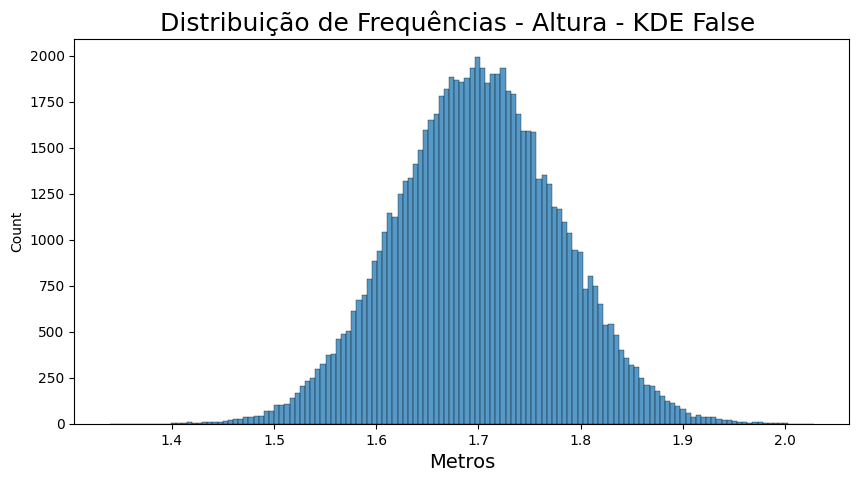

In [ ]:
ax = sns.histplot(df.Altura, kde = False)

ax.figure.set_size_inches(10, 5)
ax.set_title('Distribuição de Frequências - Altura - KDE False ', fontsize=18)
ax.set_xlabel('Metros', fontsize=14)
ax

<Axes: title={'center': 'Distribuição de Frequências - Altura - KDE TRUE'}, xlabel='Metros', ylabel='Count'>

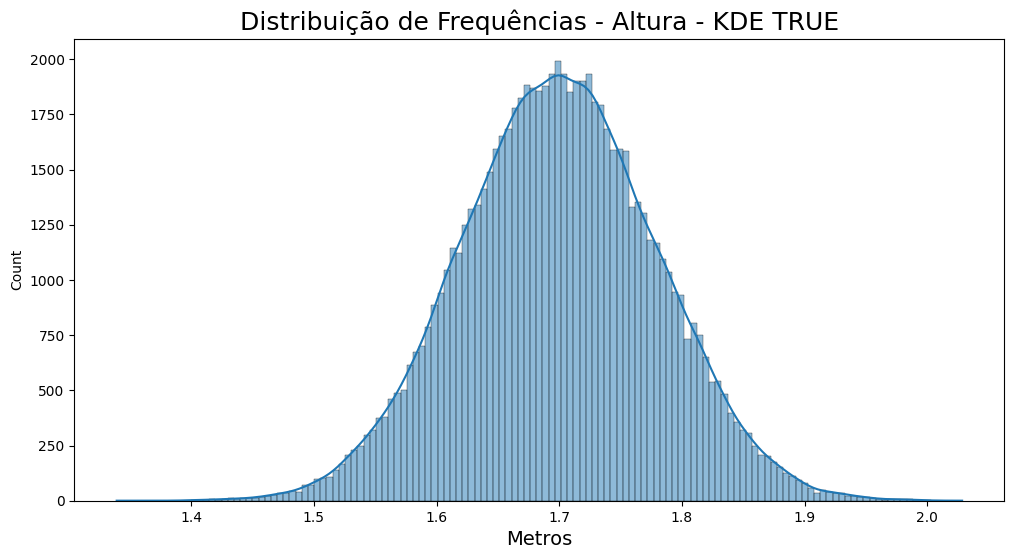

In [ ]:
ax = sns.histplot(df.Altura, kde = True)

ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuição de Frequências - Altura - KDE TRUE', fontsize=18)
ax.set_xlabel('Metros', fontsize=14)
ax

In [ ]:
dist_freq_quantitativas

,index,Renda,frequencia,Porcentagem (%)
0,4,A,349,0.5
1,3,B,2178,2.8
2,2,C,7599,9.9
3,1,D,16700,21.8
4,0,E,49755,65.0


<Axes: >

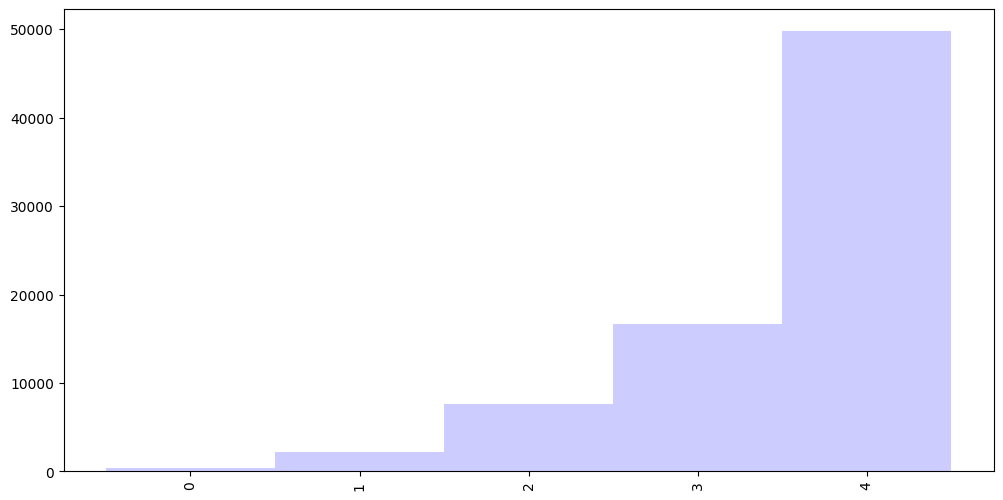

In [ ]:
# forma de fazer grafico usando o pandas

dist_freq_quantitativas['frequencia'].plot.bar(width= 1, color= 'blue', alpha = 0.2, figsize= (12, 6))

# Medidas de tendencia central - Aula 3

In [ ]:
notas = pd.DataFrame(data = {'Fulano': [8, 10, 4, 8, 6, 10, 8],
                          'Beltrano': [10, 2, 0.5, 1, 3, 9.5, 10],
                          'Sicrano': [7.5, 8, 7, 8, 8, 8.5, 7]},
                 index = ['Matemática',
                          'Português',
                          'Inglês',
                          'Geografia',
                          'História',
                          'Física',
                          'Química'])
df.rename_axis('Matérias', axis = 'columns', inplace = True)
df

Matérias,UF,Sexo,Idade,Cor,Anos de Estudo,Renda,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631
...,...,...,...,...,...,...,...
76835,53,1,46,2,11,812,1.687030
76836,53,0,30,4,7,1500,1.792934
76837,53,0,32,8,12,1300,1.830587
76838,53,0,57,8,4,1500,1.726344


### media

In [ ]:
notas['Fulano'].mean()

np.float64(7.714285714285714)

In [ ]:
df['Renda'].mean()

np.float64(2000.3831988547631)

In [ ]:
# Jeito errado de pesquisar
df.groupby(['Sexo']).mean()

,UF,Idade,Cor,Anos de Estudo,Renda,Altura
Sexo,,,,,,
0,31.901991,44.046554,5.038685,9.120169,2192.441596,1.699443
1,31.937728,44.127554,5.018906,10.258584,1566.847393,1.699670


In [ ]:
# Com esta execução, o sistema calculará a média por outra coluna
df.groupby(['Sexo'])['Renda'].mean()

,Renda
Sexo,
0,2192.441596
1,1566.847393


In [ ]:
# exercicio 1
dataset = pd.DataFrame({
    'Sexo': ['H', 'M', 'M', 'M', 'M', 'H', 'H', 'H', 'M', 'M'],
    'Idade': [53, 72, 54, 27, 30, 40, 58, 32, 44, 51]
})

media = dataset['Idade'].mean()
print(media)

46.1


In [ ]:
# exercicio 2
dataset = pd.DataFrame({
    'Sexo': ['H', 'M', 'M', 'M', 'M', 'H', 'H', 'H', 'M', 'M'],
    'Idade': [53, 72, 54, 27, 30, 40, 58, 32, 44, 51]
})

dataset.groupby(['Sexo']).mean().loc['H']


,H
Idade,45.75


### mediana

mediana impar

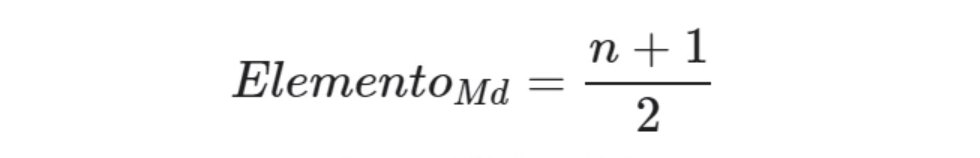

mediana par

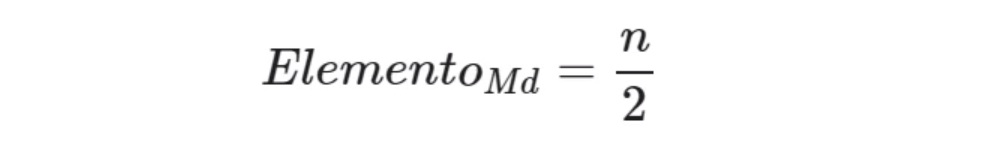

In [ ]:
notas = pd.DataFrame(data = {'Fulano': [8, 10, 4, 8, 6, 10, 8],
                          'Beltrano': [10, 2, 0.5, 1, 3, 9.5, 10],
                          'Sicrano': [7.5, 8, 7, 8, 8, 8.5, 7]},
                 index = ['Matemática',
                          'Português',
                          'Inglês',
                          'Geografia',
                          'História',
                          'Física',
                          'Química'])
notas.rename_axis('Matérias', axis = 'columns', inplace = True)
notas

Matérias,Fulano,Beltrano,Sicrano
Matemática,8,10.0,7.5
Português,10,2.0,8.0
Inglês,4,0.5,7.0
Geografia,8,1.0,8.0
História,6,3.0,8.0
Física,10,9.5,8.5
Química,8,10.0,7.0


In [ ]:
notas_fulano = notas['Fulano']
notas_fulano

,Fulano
Matemática,8
Português,10
Inglês,4
Geografia,8
História,6
Física,10
Química,8


In [ ]:
#sort.value()

notas_fulano = notas_fulano.sort_values()
notas_fulano

,Fulano
Inglês,4
História,6
Geografia,8
Matemática,8
Química,8
Português,10
Física,10


In [ ]:
#reset_index()

notas_fulano = notas_fulano.reset_index()
notas_fulano

,index,Fulano
0,Inglês,4
1,História,6
2,Geografia,8
3,Matemática,8
4,Química,8
5,Português,10
6,Física,10


In [ ]:
n = notas_fulano.shape[0]
print(f'o tamanho é: {n}')
print('-'*50)

# mediana
elemento_md = (n + 1) / 2
elemento_md

o tamanho é: 7
--------------------------------------------------


4.0

In [ ]:
# df.loc[linhas, colunas] Seleciona linhas e colunas pelos rótulos (labels).
notas_fulano.loc[elemento_md - 1]

,3
index,Matemática
Fulano,8


In [ ]:
notas_fulano['Fulano'].median()

8.0

In [ ]:
# df.sample()   Retorna uma amostra aleatória do DataFrame.
notas_beltrano = notas.Beltrano.sample(6, random_state = 101)
notas_beltrano

,Beltrano
Matemática,10.0
Inglês,0.5
Física,9.5
História,3.0
Química,10.0
Português,2.0


In [ ]:
notas_beltrano = notas_beltrano.sort_values()
notas_beltrano

,Beltrano
Inglês,0.5
Português,2.0
História,3.0
Física,9.5
Matemática,10.0
Química,10.0


In [ ]:
notas_beltrano = notas_beltrano.reset_index()
notas_beltrano

,index,Beltrano
0,Inglês,0.5
1,Português,2.0
2,História,3.0
3,Física,9.5
4,Matemática,10.0
5,Química,10.0


In [ ]:
n = notas_beltrano.shape[0]

elemento_md_par = (n) / 2
elemento_md_par

3.0

In [ ]:
notas_beltrano.loc[elemento_md_par - 1]

,2
index,História
Beltrano,3.0


In [ ]:
notas_beltrano['Beltrano'].median()

6.25

Mediana do df

In [ ]:
df['Renda'].median()

1200.0

In [ ]:
# outro modo usando um assunto mais pra frente
df.Renda.quantile()

np.float64(1200.0)

### moda

é o valor que aparece com maior frequência em um conjunto de dados

expressão -> elemento.mode()

In [ ]:
notas

Matérias,Fulano,Beltrano,Sicrano
Matemática,8,10.0,7.5
Português,10,2.0,8.0
Inglês,4,0.5,7.0
Geografia,8,1.0,8.0
História,6,3.0,8.0
Física,10,9.5,8.5
Química,8,10.0,7.0


In [ ]:
notas.mode()

Matérias,Fulano,Beltrano,Sicrano
0,8,10.0,8.0


In [ ]:
# Exercicio
exercicio = pd.Series(['Big Mac', 'Quarteirão', 'Big Mac', 'Big Mac', 'Cheeseburguer',
                   'Big Mac', 'Quarteirão', 'Quarteirão', 'Mc Fish', 'Quarteirão',
                   'Cheeseburguer'])

exercicio.mode()

,0
0,Big Mac
1,Quarteirão


### Relação entre media, mediana e moda

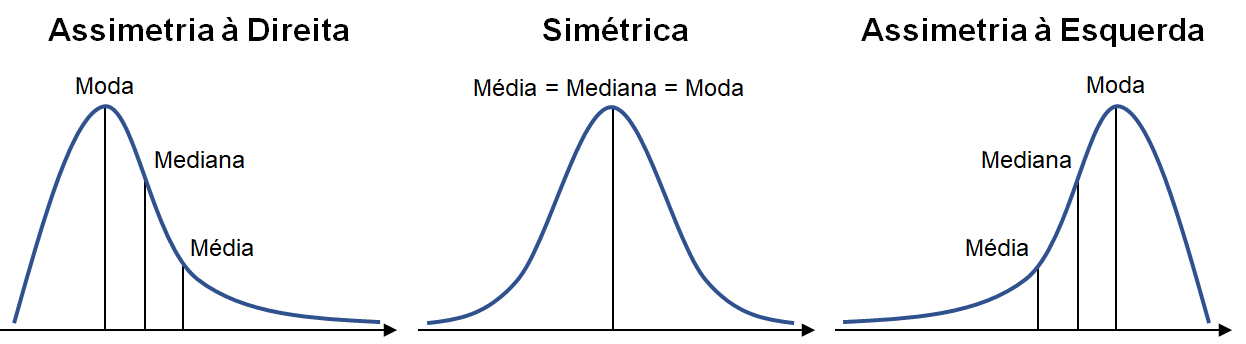

<Axes: xlabel='Renda', ylabel='Count'>

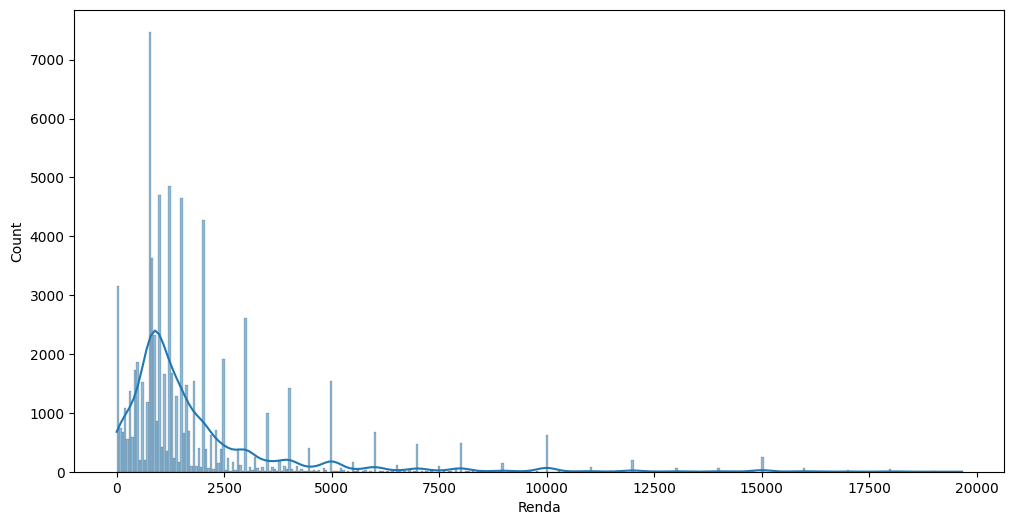

In [ ]:
ax = sns.histplot(df.query('Renda < 20000').Renda, kde = True)
ax.figure.set_size_inches(12, 6)
ax

In [ ]:
Moda = df.Renda.mode()[0]
print(Moda)

print('-'*50)
Mediana = df.Renda.median()
print(Mediana)

print('-'*50)
Media = df.Renda.mean()
print(Media)

print('-'*50)
Moda < Mediana < Media

788
--------------------------------------------------
1200.0
--------------------------------------------------
2000.3831988547631
--------------------------------------------------


np.True_

# Medidas Separatrizes - Aula 4

### Quartiz, Decis e Percentis

Quartis    # Separam os dados em 4 grupos com 25% dos valores cada.

Decis      # Separam os dados em 10 grupos com 10% dos valores cada.

Percentis  # Separam os dados em 100 grupos com 1% dos valores cada.

In [ ]:
# quantile usando lista pequena
df['Renda'].quantile([0.25, 0.5, 0.75])

,Renda
0.25,788.0
0.50,1200.0
0.75,2000.0


In [ ]:
# quantile usando lista com inumeros valores
df['Idade'].quantile([i / 5 for i in range(1, 5)])


,Idade
0.2,33.0
0.4,40.0
0.6,47.0
0.8,55.0


<Axes: title={'center': 'Distribuição de Frequências Acumulada'}, xlabel='Anos', ylabel='Acumulado'>

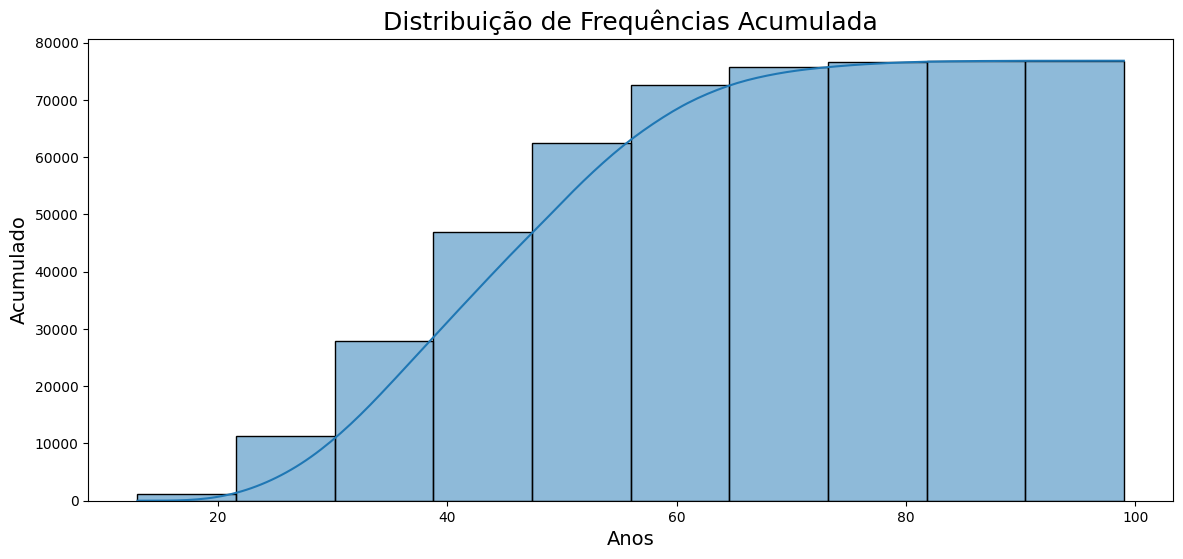

In [ ]:
# codigo para fazer tabelas

ax = sns.histplot(df.Idade,
                  cumulative = True,
                  kde = True,
                  bins = 10)
ax.figure.set_size_inches(14, 6)
ax.set_title('Distribuição de Frequências Acumulada', fontsize=18)
ax.set_ylabel('Acumulado', fontsize=14)
ax.set_xlabel('Anos', fontsize=14)
ax

### Box-plot

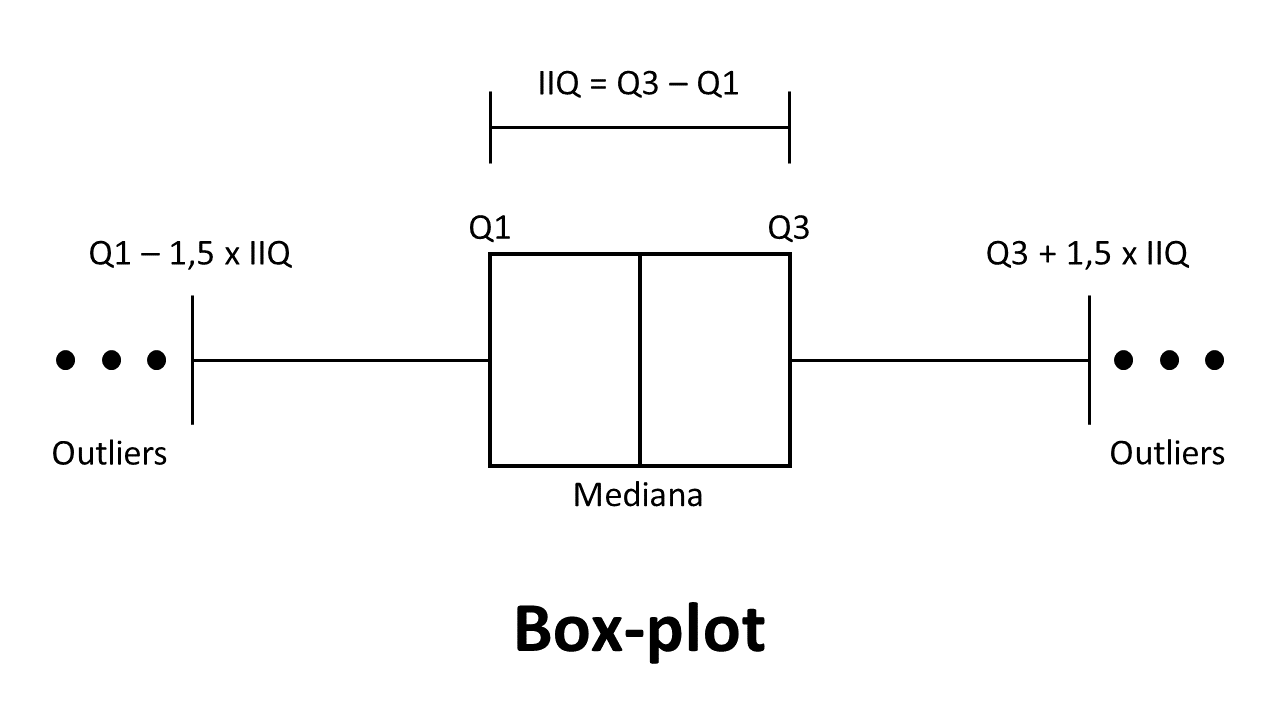

<Axes: title={'center': 'Altura'}, xlabel='Metros'>

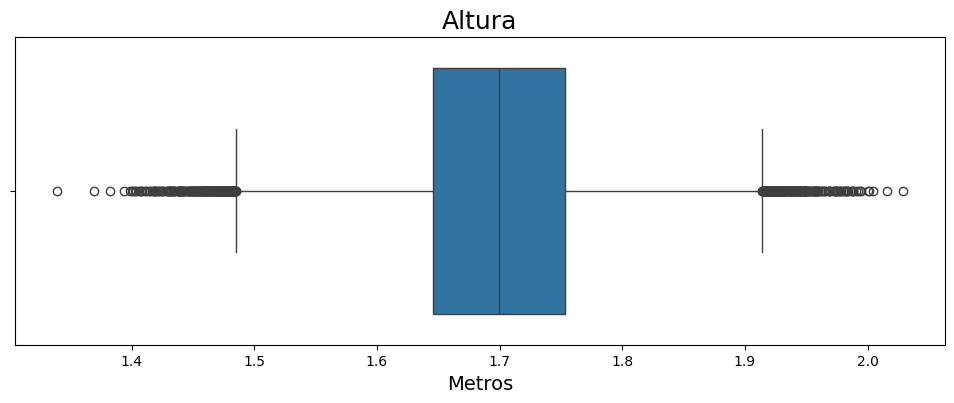

In [ ]:
# com uma variavel
ax = sns.boxplot( x = 'Altura', data = df, orient = 'h')
ax.figure.set_size_inches(12, 4)
ax.set_title('Altura', fontsize=18)
ax.set_xlabel('Metros', fontsize=14)
ax

<Axes: title={'center': 'Anos de Estudo'}, xlabel='Anos', ylabel='Sexo'>

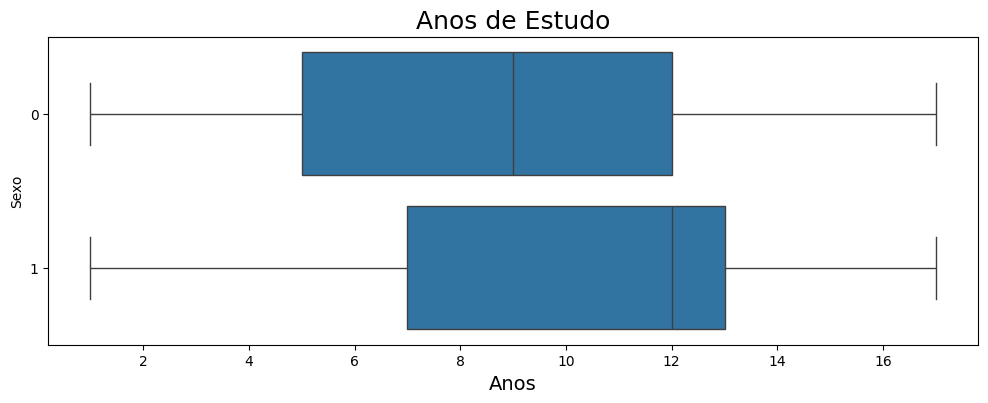

In [ ]:
# com duas ou mais variaveis
ax = sns.boxplot( x = 'Anos de Estudo', y = 'Sexo', data = df, orient = 'h')
ax.figure.set_size_inches(12, 4)
ax.set_title('Anos de Estudo', fontsize=18)
ax.set_xlabel('Anos', fontsize=14)
ax

<Axes: title={'center': 'Renda (R$) - Bahia X São Paulo'}, xlabel='R$', ylabel='UF'>

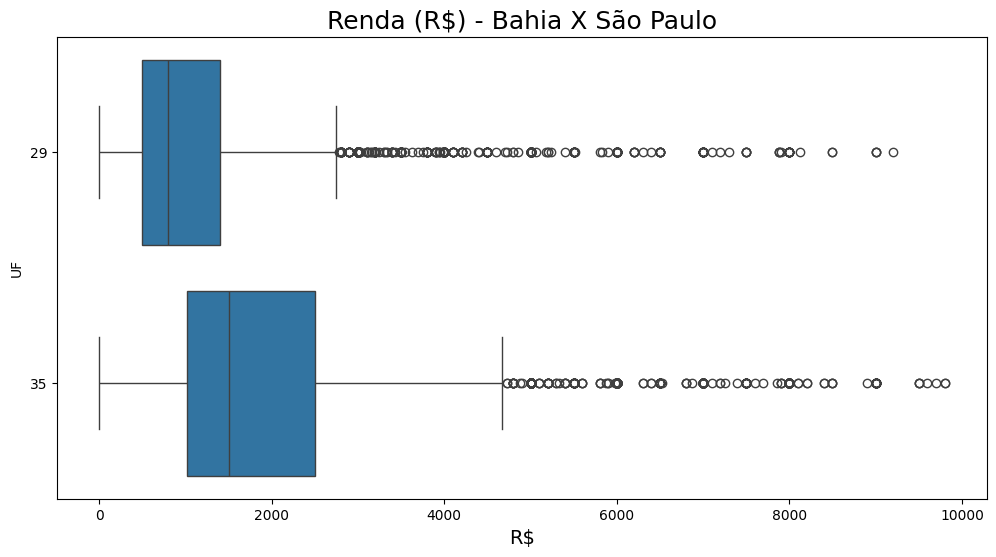

In [ ]:
# utilizando querry com varias informações
ax = sns.boxplot(x = 'Renda', y = 'UF', data = df.query('(UF==35 or UF==29) and Renda < 10000'), orient = 'h')

ax.figure.set_size_inches(12, 6)
ax.set_title('Renda (R$) - Bahia X São Paulo', fontsize=18)
ax.set_xlabel('R$', fontsize=14)
ax

# Medidas de dispersão - Aula 5

### Desvio medio absoluto

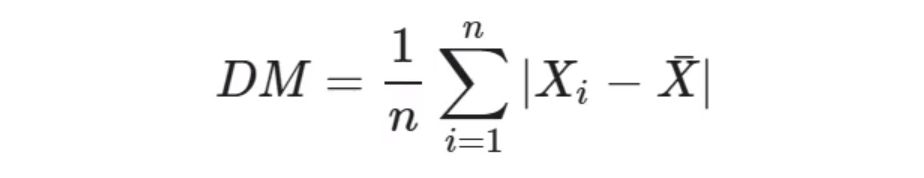

In [ ]:
notas

Matérias,Fulano,Beltrano,Sicrano
Matemática,8,10.0,7.5
Português,10,2.0,8.0
Inglês,4,0.5,7.0
Geografia,8,1.0,8.0
História,6,3.0,8.0
Física,10,9.5,8.5
Química,8,10.0,7.0


In [ ]:
notas.mean()

,0
Fulano,7.714286
Beltrano,5.142857
Sicrano,7.714286


In [ ]:
notas.median()

,0
Fulano,8.0
Beltrano,3.0
Sicrano,8.0


In [ ]:
notas_fulano = notas['Fulano']
notas_fulano

,Fulano
Matemática,8
Português,10
Inglês,4
Geografia,8
História,6
Física,10
Química,8


In [ ]:
# criando um DataFrame com Pandas.Usa-se [[]]
notas_fulano = notas[['Fulano']].copy()
notas_fulano

Matérias,Fulano
Matemática,8
Português,10
Inglês,4
Geografia,8
História,6
Física,10
Química,8


In [ ]:
nota_media_fulano = notas_fulano.mean()
nota_media_fulano

,0
Matérias,
Fulano,7.714286


In [ ]:
notas_fulano['Desvio'] = notas_fulano - nota_media_fulano.iloc[0]
notas_fulano

Matérias,Fulano,Desvio
Matemática,8,0.285714
Português,10,2.285714
Inglês,4,-3.714286
Geografia,8,0.285714
História,6,-1.714286
Física,10,2.285714
Química,8,0.285714


In [ ]:
desvio_medio_absoluto = notas_fulano['Desvio'].mean()
desvio_medio_absoluto

np.float64(-1.2688263138573217e-16)

In [ ]:
notas_fulano['Desvio'].sum()

np.float64(-8.881784197001252e-16)

In [ ]:
# utiliza-se o .abs() para retirr os valores negativos pois para utilizar a
# formula do desvio medio absoluto precisa estar positivo

notas_fulano['|Desvio|'] = notas_fulano['Desvio'].abs()
notas_fulano

,Fulano,Desvio,|Desvio|
Matemática,8,0.285714,0.285714
Português,10,2.285714,2.285714
Inglês,4,-3.714286,3.714286
Geografia,8,0.285714,0.285714
História,6,-1.714286,1.714286
Física,10,2.285714,2.285714
Química,8,0.285714,0.285714


/tmp/ipykernel_33641/1318873745.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.vlines(x = i, ymin = nota_media_fulano, ymax = notas_fulano['Fulano'][i], linestyle='dashed')


<Axes: >

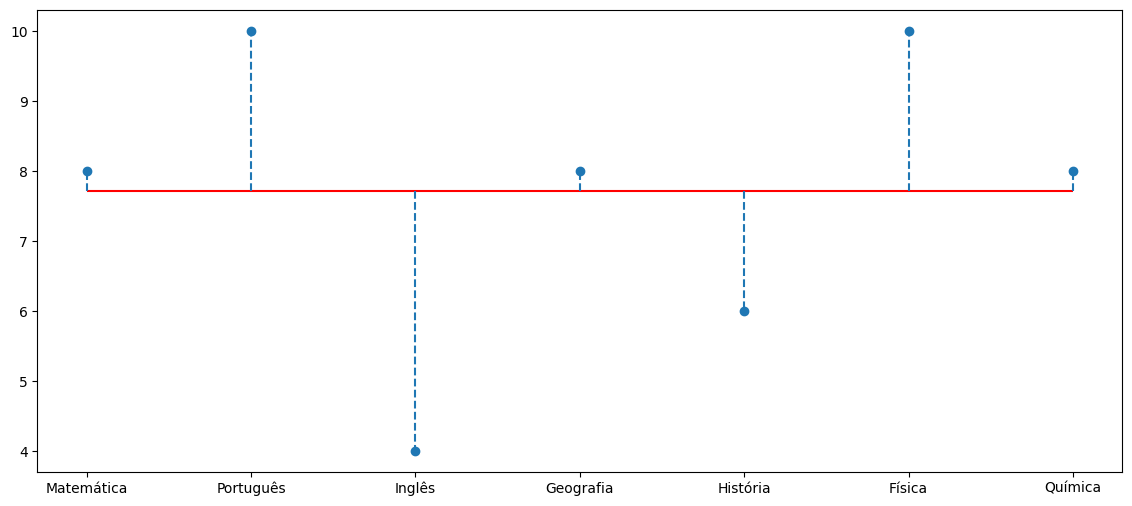

In [ ]:
# professor disse para não se preocupar com essa tabela

ax = notas_fulano['Fulano'].plot(style = 'o')
ax.figure.set_size_inches(14, 6)
ax.hlines(y = nota_media_fulano, xmin = 0, xmax = notas_fulano.shape[0] - 1, colors = 'red')
for i in range(notas_fulano.shape[0]):
    ax.vlines(x = i, ymin = nota_media_fulano, ymax = notas_fulano['Fulano'][i], linestyle='dashed')
ax

In [ ]:
notas_fulano['|Desvio|'].mean()

np.float64(1.5510204081632648)

### Variancia

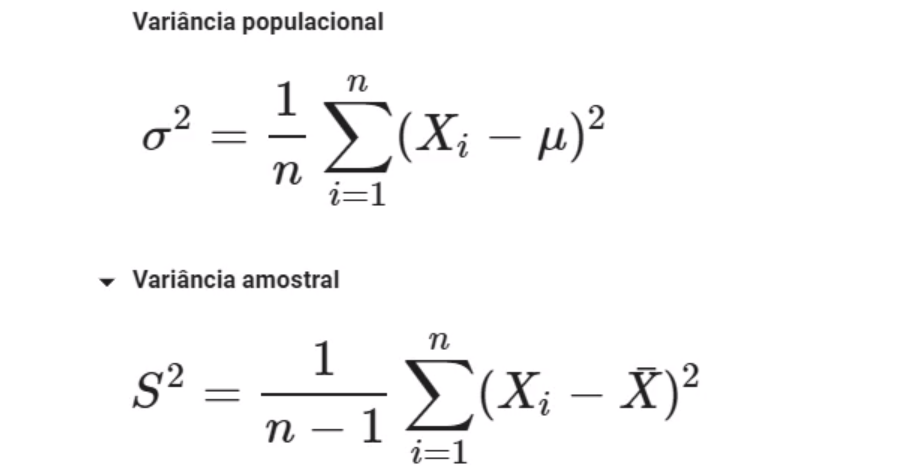

In [ ]:
notas_fulano['(Desvio)^2'] = notas_fulano['Desvio'].pow(2)
notas_fulano

,Fulano,Desvio,|Desvio|,(Desvio)^2
Matemática,8,0.285714,0.285714,0.081633
Português,10,2.285714,2.285714,5.224490
Inglês,4,-3.714286,3.714286,13.795918
Geografia,8,0.285714,0.285714,0.081633
História,6,-1.714286,1.714286,2.938776
Física,10,2.285714,2.285714,5.224490
Química,8,0.285714,0.285714,0.081633


In [ ]:
# variancia amostral
notas_fulano['(Desvio)^2'].sum() / (len(notas_fulano) - 1)

np.float64(4.57142857142857)

In [ ]:
# variancia amostral
variancia = notas_fulano['Fulano'].var()
variancia

4.57142857142857

### Desvio padrão

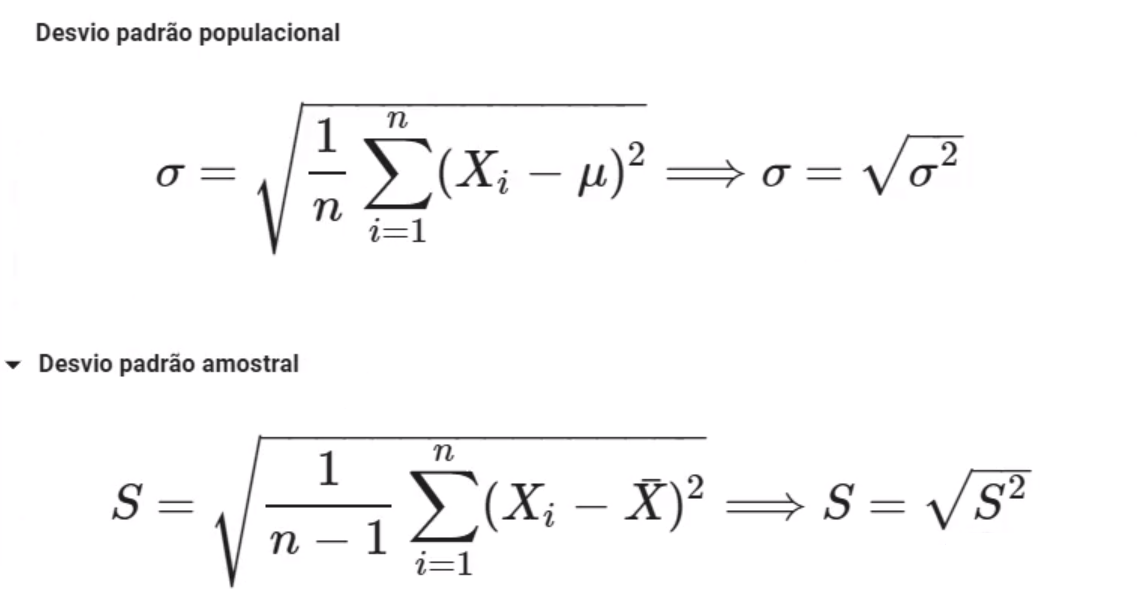

In [ ]:
# forma usando numpy
np.sqrt(variancia)

np.float64(2.1380899352993947)

In [ ]:
# desvio padrão amostral
desvio_padrao = notas_fulano['Fulano'].std()
desvio_padrao

2.1380899352993947

In [ ]:
notas.std()

,0
Fulano,2.138090
Beltrano,4.460141
Sicrano,0.566947


In [ ]:
#Exercicio 1
dataset = pd.DataFrame({
    'Sexo': ['H', 'M', 'M', 'M', 'M', 'H', 'H', 'H', 'M', 'M'],
    'Idade': [53, 72, 54, 27, 30, 40, 58, 32, 44, 51]
})

idade = dataset['Idade'].std()
idade

14.184890239656813

In [ ]:
#Exercicio 2

idade = dataset[dataset['Sexo'] == 'M']['Idade'].std()
idade

16.64531966249572